# Neuroblastoma Transcriptomic Profiling for Clinical Outcome Prediction

### Project Overview

This notebook presents an end-to-end machine learning workflow for predicting clinical outcomes in neuroblastoma using transcriptomic and clinical data from the GSE49711 cohort of 498 primary tumours. The central aim is to evaluate whether tumour transcriptomic profiles contain sufficient predictive signal to classify clinically relevant endpoints.

### Objectives

1. Integrate RNA-seq and clinical data for neuroblastoma samples  
2. Perform exploratory analysis and PCA to assess data structure  
3. Apply variance-based feature selection (training data only)  
4. Develop supervised ML models (Logistic Regression, SVM, Random Forest)  
5. Evaluate performance using cross-validation and a held-out test set  
6. Perform Random Forest feature importance analysis  
7. Predict high-risk status in unlabelled samples  
8. Interpret results and discuss limitations

### 1. Data Integration

#### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import os
import matplotlib.patches as mpatches

#### Load Data

In [2]:
# define data directory
data_dir = 'DataSet'

# file names
fn_fpkm = 'log2FPKM.tsv'
fn_patient_info = 'patientInfo.tsv'

# load RNA-Seq data (log2 FPKM values)
df_fpkm = pd.read_csv(f"{data_dir}/{fn_fpkm}", sep='\t')

# check data shape
df_fpkm = df_fpkm.rename({'00gene_id': 'gene_id'}, axis=1)
df_fpkm = df_fpkm.set_index('gene_id')
df_fpkm.columns.name = 'ID'

print(f" RNA-Seq data shape: {df_fpkm.shape}")
print(f" Number of genes: {df_fpkm.shape[0]}")
print(f" Number of samples: {df_fpkm.shape[1]}")

# check first few data rows
df_fpkm.head()

 RNA-Seq data shape: (23146, 498)
 Number of genes: 23146
 Number of samples: 498


ID,NB001,NB002,NB003,NB004,NB005,NB006,NB007,NB008,NB009,NB010,...,NB489,NB490,NB491,NB492,NB493,NB494,NB495,NB496,NB497,NB498
gene_id,,,,,,,,,,,,,,,,,,,,,
1/2-SBSRNA4,0.834381,0.743094,0.909414,0.795775,0.905540,0.869154,1.811352,0.599240,0.981855,1.066399,...,0.997977,1.003559,0.842437,1.057873,0.805515,0.491331,0.868249,0.911379,0.660139,1.152988
A1BG,1.910053,0.941996,1.950857,1.989477,1.942946,1.927608,1.617745,2.161291,1.436439,2.159797,...,2.336929,2.836360,1.205317,2.439868,1.649027,1.451425,1.493852,1.641241,1.994978,1.289534
A1BG-AS1,1.453191,0.640614,1.156765,1.525277,1.365043,0.899212,1.304178,1.189205,0.771248,1.114787,...,1.182908,1.367371,0.643751,1.096815,0.925425,0.933275,1.208723,0.904511,1.529221,1.102866
A1CF,0.005102,0.005902,0.005192,0.000000,0.025347,0.005682,0.000000,0.000000,0.021880,0.000000,...,0.024298,0.007295,0.000000,0.006678,0.005746,0.004998,0.004853,0.000000,0.022780,0.018720
A2LD1,0.580151,0.738233,0.927667,0.936497,0.924853,0.739038,1.018705,0.546324,0.666877,0.865850,...,0.673627,1.401265,0.837443,0.939849,0.743496,0.957837,0.812093,0.488748,1.068072,0.782887


In [3]:
# load patient clinical information
df_patient_info = pd.read_csv(f'{data_dir}/{fn_patient_info}', sep='\t')

# check data shape
df_patient_info = df_patient_info.set_index('ID')
df_patient_info.columns.name = 'FactorValues'

print(f"Patient info shape: {df_patient_info.shape}")
print(f"Clinical features: {list(df_patient_info.columns)}")

# check first few data rows
df_patient_info.head()

Patient info shape: (498, 6)
Clinical features: ['FactorValue..Sex.', 'FactorValue..age.at.diagnosis.', 'FactorValue..death.from.disease.', 'FactorValue..high.risk.', 'FactorValue..inss.stage.', 'FactorValue..progression.']


FactorValues,FactorValue..Sex.,FactorValue..age.at.diagnosis.,FactorValue..death.from.disease.,FactorValue..high.risk.,FactorValue..inss.stage.,FactorValue..progression.
ID,,,,,,
NB498,female,530,NaN,NaN,NaN,NaN
NB497,female,379,0.0,0.0,1,0.0
NB496,male,132,NaN,NaN,NaN,NaN
NB495,male,163,0.0,0.0,1,0.0
NB494,male,56,NaN,NaN,NaN,NaN


#### Sample Alignment

In [4]:
# compare sample IDs between expression and clinical data
expr_samples = set(df_fpkm.columns)
clinical_samples = set(df_patient_info.index)

print(f"Samples in expression data: {len(expr_samples)}")
print(f"Samples in clinical data: {len(clinical_samples)}")
print(f"Common samples: {len(expr_samples.intersection(clinical_samples))}")

Samples in expression data: 498
Samples in clinical data: 498
Common samples: 168


The sample IDs didn’t match between the expression data and clinical data at first. This was because the RNA-seq IDs had extra suffixes, which were removed to align them with the clinical IDs.

In [5]:
# clean expression column names
df_fpkm.columns = df_fpkm.columns.str.strip()

# clean clinical index
df_patient_info.index = df_patient_info.index.str.strip()

# extract base IDs (NBxxx) from expression columns
df_fpkm.columns = df_fpkm.columns.str.extract(r'(NB\d+)')[0]

In [6]:
# check overlap after alignment
expr_samples = set(df_fpkm.columns)
clinical_samples = set(df_patient_info.index)

print(f"Common samples after cleaning: {len(expr_samples.intersection(clinical_samples))}")

Common samples after cleaning: 498


### 2. Exploratory Data Analysis

#### Missingness Checks

Clinical endpoints were explored to check how complete the data was and how the classes were distributed. This helps decide which targets to use, as missing labels and class imbalance can affect model performance.

In [7]:
# check how many missing values exist in each clinical variable
# helps understand which endpoints can be used for modelling

missing_counts = df_patient_info.isnull().sum().sort_values(ascending=False)

print("Missing values per clinical variable:")
print(missing_counts)

Missing values per clinical variable:
FactorValues
FactorValue..high.risk.             249
FactorValue..death.from.disease.    249
FactorValue..inss.stage.            249
FactorValue..progression.           249
FactorValue..age.at.diagnosis.        0
FactorValue..Sex.                     0
dtype: int64


In [8]:
# define main clinical endpoints 
endpoints = [
    'FactorValue..high.risk.',
    'FactorValue..progression.',
    'FactorValue..death.from.disease.'
]

# check missing values for these endpoints
print("\nMissing values in key endpoints:")
print(df_patient_info[endpoints].isnull().sum())


Missing values in key endpoints:
FactorValues
FactorValue..high.risk.             249
FactorValue..progression.           249
FactorValue..death.from.disease.    249
dtype: int64


Exploration of the clinical metadata showed that only half of the cohort has recorded outcome labels, while the remainder is unlabelled, suggesting a predefined split between labelled and unlabelled samples. 

#### Class Distribution Checks

In [9]:
# check distribution of classes for each endpoint
# tells us whether the dataset is balanced or imbalanced

for endpoint in endpoints:
    print(f"\nClass distribution for {endpoint}:")
    print(df_patient_info[endpoint].value_counts())


Class distribution for FactorValue..high.risk.:
FactorValue..high.risk.
0.0    163
1.0     86
Name: count, dtype: int64

Class distribution for FactorValue..progression.:
FactorValue..progression.
0.0    160
1.0     89
Name: count, dtype: int64

Class distribution for FactorValue..death.from.disease.:
FactorValue..death.from.disease.
0.0    198
1.0     51
Name: count, dtype: int64


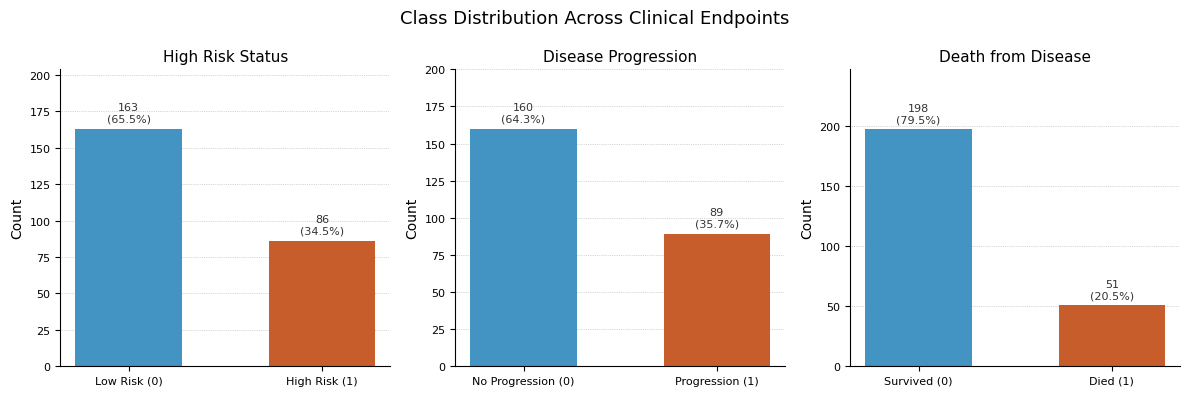

In [10]:
# class distribution across main clinical endpoints
COLOR_0 = '#4393C3'
COLOR_1 = '#C65D2B'
colors = [COLOR_0, COLOR_1]

# readable endpoint titles
endpoint_labels = {
    'FactorValue..high.risk.': 'High Risk Status',
    'FactorValue..progression.': 'Disease Progression',
    'FactorValue..death.from.disease.': 'Death from Disease'
}

# clinically meaningful class labels
label_maps = {
    'FactorValue..high.risk.': {0: 'Low Risk', 1: 'High Risk'},
    'FactorValue..progression.': {0: 'No Progression', 1: 'Progression'},
    'FactorValue..death.from.disease.': {0: 'Survived', 1: 'Died'}
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, endpoint in enumerate(endpoints):
    ax = axes[i]

    # count class labels
    counts = df_patient_info[endpoint].value_counts().sort_index()
    total = counts.sum()

    # clinical meaning first, numeric encoding second
    x_labels = [f"{label_maps[endpoint][int(c)]} ({int(c)})" for c in counts.index]

    bars = ax.bar(
        x_labels,
        counts.values,
        color=colors[:len(counts)],
        width=0.55
    )

    # annotate bars with count and percentage
    for bar, val in zip(bars, counts.values):
        pct = val / total * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + total * 0.015,
            f'{val}\n({pct:.1f}%)',
            ha='center',
            va='bottom',
            fontsize=8,
            color='#333333'
        )

    ax.set_title(endpoint_labels[endpoint], fontsize=11)
    ax.set_ylabel('Count')
    ax.set_xlabel('')
    ax.set_ylim(0, counts.max() * 1.25)

    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, linestyle=':', linewidth=0.5)
    ax.set_axisbelow(True)
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

fig.suptitle('Class Distribution Across Clinical Endpoints', fontsize=13)

plt.tight_layout()
plt.savefig('plots/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

Class distributions show some imbalance for high-risk status and disease progression, while death from disease is more heavily imbalanced with fewer positive cases. Based on this, high-risk status was chosen as the initial target, as it is more balanced and suitable for model training.

#### Distribution of Gene Expression Values

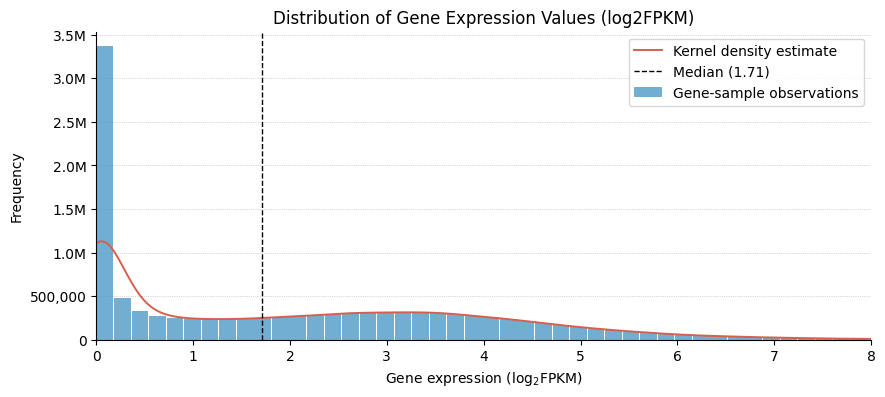

In [11]:
from scipy.stats import gaussian_kde
import matplotlib.ticker as mticker

# flatten expression matrix + remove missing values
values = df_fpkm.values.flatten()
values = values[~np.isnan(values)]

# clip tiny negative values so histogram starts at 0
values = np.clip(values, 0, None)

# summary statistic
median_val = np.median(values)

# histogram bins
counts, bin_edges = np.histogram(values, bins=100, range=(0, values.max()))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

# KDE on a random subsample for speed
rng = np.random.default_rng(seed=42)
kde_sample = rng.choice(values, size=min(50_000, len(values)), replace=False)
kde = gaussian_kde(kde_sample, bw_method=0.12)
x_range = np.linspace(0, values.max(), 1000)
kde_scaled = kde(x_range) * len(values) * bin_width

# plot
fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(
    bin_centers,
    counts,
    width=bin_width * 0.95,
    color='#4393C3',
    alpha=0.75,
    label='Gene-sample observations'
)

ax.plot(
    x_range,
    kde_scaled,
    color='#D6604D',
    linewidth=1.4,
    label='Kernel density estimate'
)

ax.axvline(
    median_val,
    color='black',
    linestyle='--',
    linewidth=1,
    label=f'Median ({median_val:.2f})'
)

ax.set_title('Distribution of Gene Expression Values (log2FPKM)')
ax.set_xlabel('Gene expression (log$_2$FPKM)')
ax.set_ylabel('Frequency')

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{int(x):,}'
    )
)

ax.set_xlim(0, 8)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle=':', linewidth=0.5)
ax.set_axisbelow(True)

ax.legend(loc='upper right')

plt.savefig('plots/gene_expression_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

The gene expression distribution is highly right-skewed, with most genes expressed at low levels and a smaller subset showing higher expression. This pattern is characteristic of RNA-seq data, and the use of log₂FPKM values results in a stabilised distribution suitable for downstream machine learning analysis.

### 3. Unsupervised Analysis

Unsupervised analysis using PCA was performed to explore overall data structure and assess potential outliers. This was used for visualisation only and was not included in the supervised modelling pipeline. A second PCA on labelled samples was used to assess whether high-risk groups show distinct transcriptomic patterns.

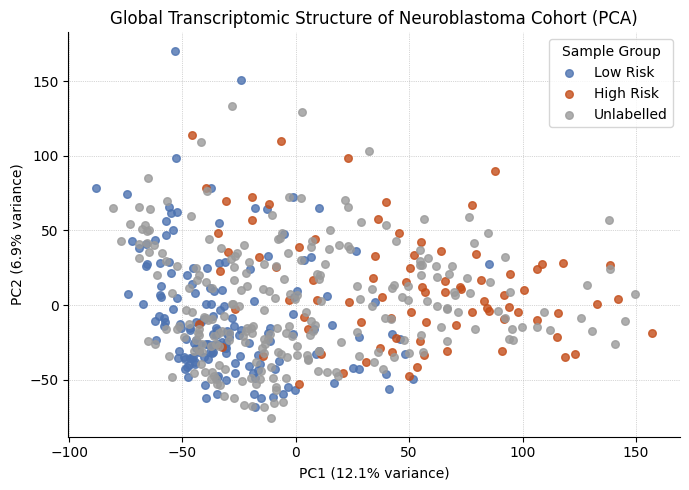

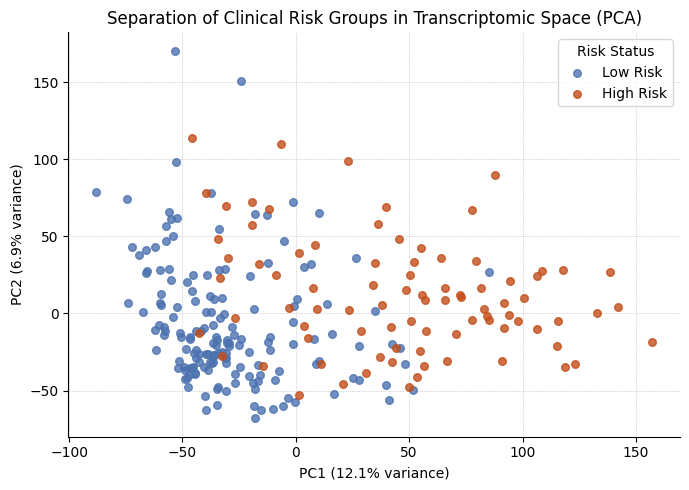

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# transpose so rows = samples, columns = genes
X = df_fpkm.T

# standardise features (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# apply PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# variance explained
explained_var = pca.explained_variance_ratio_

# create df
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=X.index)

# add clinical labels
target = 'FactorValue..high.risk.'
pca_df[target] = df_patient_info.loc[pca_df.index, target]

# map labels to readable format
pca_df['Risk'] = pca_df[target].map({
    0.0: 'Low Risk',
    1.0: 'High Risk'
}).fillna('Unlabelled')

# plot PCA (all samples)
colors = {
    'Low Risk': '#4C72B0',
    'High Risk': '#C44E1A',
    'Unlabelled': '#9A9A9A'
}

fig, ax = plt.subplots(figsize=(7, 5))

for group in ['Low Risk', 'High Risk', 'Unlabelled']:
    subset = pca_df[pca_df['Risk'] == group]
    ax.scatter(
        subset['PC1'],
        subset['PC2'],
        s=30,
        alpha=0.8,
        color=colors[group],
        label=group
    )

ax.set_title('Global Transcriptomic Structure of Neuroblastoma Cohort (PCA)')
ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}% variance)')

ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle=':', linewidth=0.5)
ax.xaxis.grid(True, linestyle=':', linewidth=0.5)
ax.set_axisbelow(True)

ax.legend(title='Sample Group')

plt.tight_layout()
plt.savefig('plots/pca_all_samples.png', dpi=300, bbox_inches='tight')
plt.show()

# plot PCA (LABELLED only)
pca_labelled = pca_df[pca_df['Risk'] != 'Unlabelled']

fig, ax = plt.subplots(figsize=(7, 5))

for group in ['Low Risk', 'High Risk']:
    subset = pca_labelled[pca_labelled['Risk'] == group]
    ax.scatter(
        subset['PC1'],
        subset['PC2'],
        s=30,
        alpha=0.8,
        color=colors[group],
        label=group
    )

ax.set_title('Separation of Clinical Risk Groups in Transcriptomic Space (PCA)')
ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}% variance)')

ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle=':', linewidth=0.5)
ax.xaxis.grid(True, linestyle=':', linewidth=0.5)
ax.set_axisbelow(True)

ax.legend(title='Risk Status')

plt.tight_layout()
plt.savefig('plots/pca_labelled_samples.png', dpi=300, bbox_inches='tight')
plt.show()

Based on exploratory analysis, transcriptomic variation shows partial association with clinical outcomes but does not fully separate classes. Therefore, supervised machine learning approaches are required to capture more subtle predictive patterns.

#### Outlier Detection 

Outliers were identified based on Euclidean distance from the centre of PCA space, providing a multivariate assessment of sample deviation. 

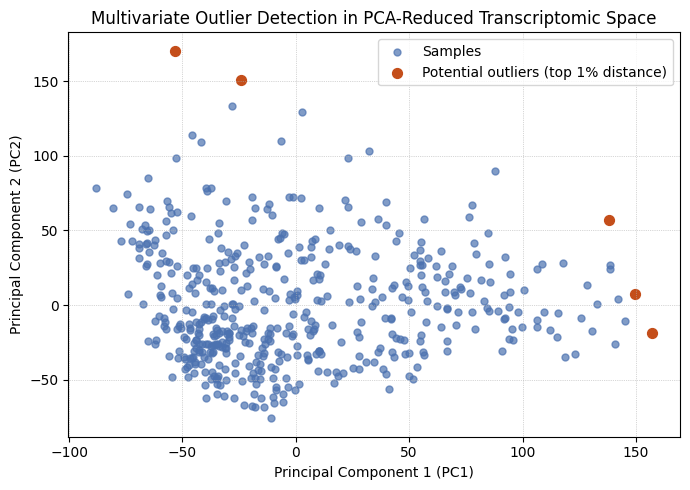

In [13]:
# multivariate outlier detection in PCA-reduced transcriptomic space

# calculate centre of PCA space
center = pca_df[['PC1', 'PC2']].mean()

# compute Euclidean distance from the PCA centre
pca_df['distance'] = np.sqrt(
    (pca_df['PC1'] - center['PC1'])**2 +
    (pca_df['PC2'] - center['PC2'])**2
)

# define outliers as the top 1% most distant samples
threshold = np.percentile(pca_df['distance'], 99)
outliers = pca_df[pca_df['distance'] > threshold]

# plot
plt.figure(figsize=(7, 5))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    color='#4C72B0',
    alpha=0.7,
    s=25,
    label='Samples'
)

plt.scatter(
    outliers['PC1'],
    outliers['PC2'],
    color='#C44E1A',
    s=50,
    label='Potential outliers (top 1% distance)'
)

plt.title('Multivariate Outlier Detection in PCA-Reduced Transcriptomic Space')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')

plt.legend()
plt.grid(True, linestyle=':', linewidth=0.5)
plt.tight_layout()
plt.show()

Outliers were kept, as they are expected in cancer datasets and may reflect real biological variation. Removing them could risk losing important patterns for the machine learning analysis.

### 4. Train-Test Split

In [14]:
from sklearn.model_selection import train_test_split

# define the prediction target
target = 'FactorValue..high.risk.'

# create a sample-by-gene matrix and add the target labels
# rows = samples, columns = genes
df_labelled = df_fpkm.T.copy()
df_labelled[target] = df_patient_info[target]

# keep only samples with known labels for supervised learning
df_labelled = df_labelled.dropna(subset=[target])

# split into features (X) and target labels (y)
X = df_labelled.drop(columns=[target])
y = df_labelled[target]

# split labelled data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,            # preserves class balance across both sets
    random_state=42
)

Data was split into training and test sets (80:20) with stratification to keep class proportions consistent.

In [15]:
# check class balance after stratified split
print("Training set distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest set distribution:")
print(y_test.value_counts(normalize=True))

Training set distribution:
FactorValue..high.risk.
0.0    0.653266
1.0    0.346734
Name: proportion, dtype: float64

Test set distribution:
FactorValue..high.risk.
0.0    0.66
1.0    0.34
Name: proportion, dtype: float64


### 5. Feature Selection

Feature selection was used to reduce the number of genes, reducing the feature space from ~23,000 to ~2,300. Variance filtering was applied on the training data only, keeping the top 10% most variable genes. These were then applied to both training and test sets to avoid data leakage.

In [16]:
# calculate gene-wise variance using the training data only
# this avoids using information from the test set
gene_variances = X_train.var(axis=0)

# keep the top 10% most variable genes
threshold = gene_variances.quantile(0.90)
selected_genes = gene_variances[gene_variances > threshold].index

# apply the selected genes to both training and test sets
X_train_sel = X_train[selected_genes]
X_test_sel = X_test[selected_genes]

# check how many genes were retained
print(f"Selected {len(selected_genes)} genes out of {X.shape[1]}")
print(f"Training set shape after selection: {X_train_sel.shape}")
print(f"Test set shape after selection: {X_test_sel.shape}")

Selected 2315 genes out of 23146
Training set shape after selection: (199, 2315)
Test set shape after selection: (50, 2315)


### 6. Supervised Analysis

Supervised machine learning models will be used to predict high-risk status from gene expression data using three models to compare different approaches: 

- logistic regression
- random forest
- support vector machine (SVM) 

#### Define Models

In [17]:
# define models to compare

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'SVM': SVC(probability=True)
}

#### Cross-Validation on Training Data

In [18]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# use stratified k-fold for class balance
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# store results for each model
cv_results = []

# loop through each model
for name, model in models.items():
    
    # create pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    # perform cross-val using ROC-AUC 
    scores = cross_val_score(
        pipeline,
        X_train_sel,
        y_train,
        cv=cv,
        scoring='roc_auc'
    )
    
    # store mean and SD of scores
    cv_results.append({
        'Model': name,
        'Mean ROC-AUC': scores.mean(),
        'SD ROC-AUC': scores.std()
    })
    
    # print results for each fold and summary stats
    print(name)
    print("Fold ROC-AUC scores:", scores)
    print(f"Mean ROC-AUC: {scores.mean():.3f}")
    print(f"SD: {scores.std():.3f}\n")

# convert results to df and sort by performance
cv_results_df = pd.DataFrame(cv_results).sort_values(
    by='Mean ROC-AUC',
    ascending=False
)

# display final comparison table
cv_results_df

Logistic Regression
Fold ROC-AUC scores: [0.97527473 0.97527473 0.95054945 0.97252747 0.94674556]
Mean ROC-AUC: 0.964
SD: 0.013

Random Forest
Fold ROC-AUC scores: [0.95879121 0.98351648 0.94505495 0.95741758 0.90680473]
Mean ROC-AUC: 0.950
SD: 0.025

SVM
Fold ROC-AUC scores: [0.96428571 0.98901099 0.94230769 0.97252747 0.90828402]
Mean ROC-AUC: 0.955
SD: 0.028



,Model,Mean ROC-AUC,SD ROC-AUC
0,Logistic Regression,0.964074,0.012693
2,SVM,0.955283,0.027904
1,Random Forest,0.950317,0.025082


Cross-validation showed consistently high performance across all models, with logistic regression achieving the highest mean ROC-AUC and the lowest variation across folds. This suggests that the relationship between gene expression and high-risk status is relatively stable and can be captured well using a linear model. Random forest and SVM also performed well, but showed slightly greater variability.

### Hyperparameter Tuning

Hyperparameter tuning was performed for the random forest model using grid search with cross-validation. This was done to improve model performance while keeping the search space simple and controlled.

In [19]:
from sklearn.model_selection import GridSearchCV

# create pipeline 
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42))
])

# define small parameter grid to tune the random forest
param_grid = {
    'model__n_estimators': [100, 200],        # number of trees
    'model__max_depth': [None, 10, 20],       # tree depth
    'model__min_samples_split': [2, 5]        # minimum samples to split a node
}

# perform grid search with cross-val
grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,                    # 5-fold cross-validation
    scoring='roc_auc',       # evaluate using ROC-AUC
    n_jobs=-1                # use all cores for speed
)

# fit grid search on training data
grid_search.fit(X_train_sel, y_train)

# print best parameters and corresponding score
print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

# extract best performing model
best_rf = grid_search.best_estimator_

Best parameters: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV score: 0.9537193575655115


Hyperparameter tuning improved random forest performance from a mean ROC-AUC of ~0.95 to ~0.96, showing a modest but consistent gain following model optimisation.

In [20]:
from sklearn.model_selection import cross_val_score

# cross-validation for tuned random forest
tuned_scores = cross_val_score(
    best_rf,
    X_train_sel,
    y_train,
    cv=5,
    scoring='roc_auc'
)

# print mean performance + variability across folds
print("Tuned RF mean:", tuned_scores.mean())
print("Tuned RF SD:", tuned_scores.std())

Tuned RF mean: 0.9537193575655115
Tuned RF SD: 0.01907056152645363


#### Model Performance Comparison 

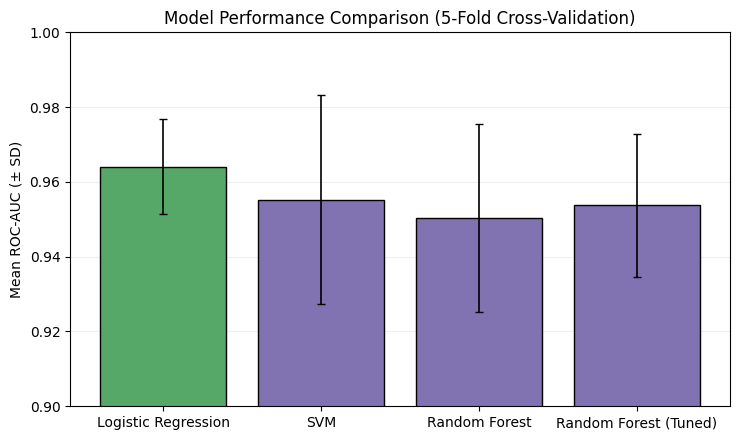

In [21]:
# add tuned random forest results to the cross-validation table

cv_results_extended = pd.concat([
    cv_results_df,
    pd.DataFrame([{
        'Model': 'Random Forest (Tuned)',
        'Mean ROC-AUC': tuned_scores.mean(),
        'SD ROC-AUC': tuned_scores.std()
    }])
], ignore_index=True)

# plot model comparison
plt.figure(figsize=(7.5, 4.5))

plt.bar(
    cv_results_extended['Model'],
    cv_results_extended['Mean ROC-AUC'],
    yerr=cv_results_extended['SD ROC-AUC'],
    capsize=3,
    color=['#55A868', '#8172B2', '#8172B2', '#8172B2'],
    edgecolor='black',
    linewidth=1,
    error_kw={'elinewidth': 1.2, 'ecolor': 'black'}
)

plt.ylabel('Mean ROC-AUC (± SD)')
plt.title('Model Performance Comparison (5-Fold Cross-Validation)')
plt.ylim(0.90, 1.00)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.2)
plt.gca().set_axisbelow(True)

plt.tight_layout()
plt.savefig('plots/cv_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Cross-validation results show consistently high performance across all models, with mean ROC-AUC values above 0.95. Logistic regression achieved the highest mean performance, while random forest showed slightly lower performance but improved after hyperparameter tuning.

The overlap in error bars indicates that differences between models are small, suggesting that performance is broadly comparable.

### Final Evaluation on the Held-Out Test Set

In [22]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd

# store test results + fitted models
test_results = []
fitted_models = {}

# evaluate baseline models on held-out test set
for name, model in models.items():
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    # train model on full training set
    pipeline.fit(X_train_sel, y_train)
    
    # predict class labels and probabilities on test set
    y_pred = pipeline.predict(X_test_sel)
    y_prob = pipeline.predict_proba(X_test_sel)[:, 1]
    
    # calculate ROC-AUC
    auc = roc_auc_score(y_test, y_prob)
    
    # store results
    test_results.append({
        'Model': name,
        'Test ROC-AUC': auc
    })
    
    # save fitted model
    fitted_models[name] = pipeline
    
    # print performance metrics
    print(name)
    print(f"Test ROC-AUC: {auc:.3f}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()

# evaluate tuned random forest separately
best_rf.fit(X_train_sel, y_train)

y_pred_tuned = best_rf.predict(X_test_sel)
y_prob_tuned = best_rf.predict_proba(X_test_sel)[:, 1]

# calculate ROC-AUC for tuned model
auc_tuned = roc_auc_score(y_test, y_prob_tuned)

# store tuned model result
test_results.append({
    'Model': 'Random Forest (Tuned)',
    'Test ROC-AUC': auc_tuned
})

fitted_models['Random Forest (Tuned)'] = best_rf

# print tuned model results
print("Random Forest (Tuned)")
print(f"Test ROC-AUC: {auc_tuned:.3f}")
print(confusion_matrix(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))
print()

# create final results table sorted by performance
test_results_df = pd.DataFrame(test_results).sort_values(
    by='Test ROC-AUC',
    ascending=False
)

# display results
test_results_df

Logistic Regression
Test ROC-AUC: 1.000
[[33  0]
 [ 0 17]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        33
         1.0       1.00      1.00      1.00        17

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50


Random Forest
Test ROC-AUC: 0.991
[[32  1]
 [ 1 16]]
              precision    recall  f1-score   support

         0.0       0.97      0.97      0.97        33
         1.0       0.94      0.94      0.94        17

    accuracy                           0.96        50
   macro avg       0.96      0.96      0.96        50
weighted avg       0.96      0.96      0.96        50


SVM
Test ROC-AUC: 0.995
[[33  0]
 [ 1 16]]
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.99        33
         1.0       1.00      0.94      0.97        17

    accuracy             

,Model,Test ROC-AUC
0,Logistic Regression,1.000000
2,SVM,0.994652
1,Random Forest,0.991087
3,Random Forest (Tuned),0.987522


All models achieved very high performance on the test set, with ROC-AUC values above 0.99. Logistic regression achieved a perfect score of 1.00, although this may reflect the small size of the test set or strong separation in the data rather than true perfect generalisation. 

#### ROC Curve

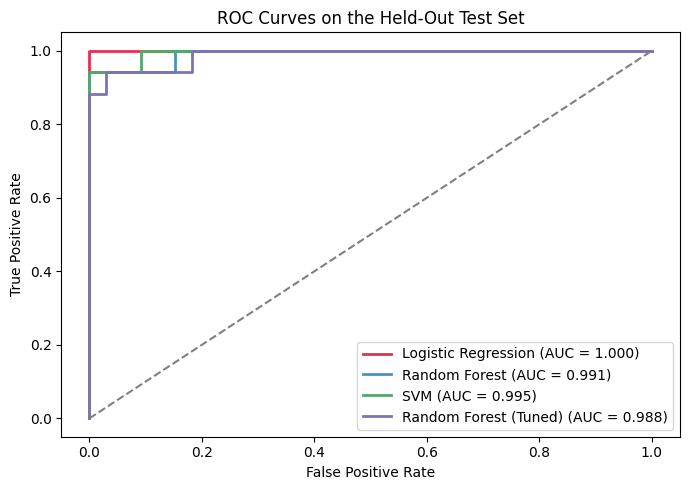

In [23]:
from sklearn.metrics import roc_curve

# plot ROC curves for all models on the test set

plt.figure(figsize=(7, 5))

# define colours for each model
colors = {
    'Logistic Regression': '#e82e50',
    'SVM': '#55A868',
    'Random Forest': '#4393C3',
    'Random Forest (Tuned)': '#8172B2'
}

# loop through fitted models + plot ROC curve
for name, pipeline in fitted_models.items():
    
    # get predicted probabilities for positive class
    y_prob = pipeline.predict_proba(X_test_sel)[:, 1]
    
    # compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    
    # calculate ROC-AUC
    auc = roc_auc_score(y_test, y_prob)
    
    # plot curve with label
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {auc:.3f})",
        color=colors[name]
    )

# diagonal reference line (random classifier)
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')

# labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves on the Held-Out Test Set')

# legend shows model performance
plt.legend()

plt.tight_layout()

# save figure
plt.savefig('plots/test_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

All models show very high performance on the test set (ROC-AUC > 0.99), with curves close to the top-left corner. Logistic regression achieved an AUC of 1.00, but this likely reflects strong class separation or the small test set rather than true perfect performance.

The similar curves across models suggest that the underlying signal is strong and can be captured by both linear and non-linear approaches.

### Prediction of High-Risk Status in Unlabelled Samples

After model evaluation, the final selected model was applied to samples without recorded high-risk labels. This was done to generate predicted high-risk classifications and associated probabilities for the unlabelled subset.

#### Logistic Regression Model Results

Logistic regression was selected as the final model due to its stability and comparable performance, as well as its interpretability.

In [24]:
# prepare unlabelled samples for prediction

target = 'FactorValue..high.risk.'

# create sample-by-gene matrix
df_unlabelled = df_fpkm.T.copy()
df_unlabelled[target] = df_patient_info[target]

# keep only samples with missing high-risk labels
df_unlabelled = df_unlabelled[df_unlabelled[target].isna()].drop(columns=[target])

print("Unlabelled samples shape:", df_unlabelled.shape)

Unlabelled samples shape: (249, 23146)


In [28]:
from sklearn.utils import resample
import numpy as np
from sklearn.metrics import roc_auc_score

# bootstrap confidence interval for final logistic regression model
proba = fitted_models['Logistic Regression'].predict_proba(X_test_sel)[:, 1]
y_test_array = np.array(y_test)

boot_aucs = []

for _ in range(1000):
    idx = resample(np.arange(len(y_test_array)))
    
    # skip resamples with only one class
    if len(np.unique(y_test_array[idx])) < 2:
        continue
    
    boot_auc = roc_auc_score(y_test_array[idx], proba[idx])
    boot_aucs.append(boot_auc)

ci_lower = np.percentile(boot_aucs, 2.5)
ci_upper = np.percentile(boot_aucs, 97.5)

print(f"Test ROC-AUC: {roc_auc_score(y_test_array, proba):.3f}")
print(f"Bootstrap 95% CI: {ci_lower:.3f}–{ci_upper:.3f}")

Test ROC-AUC: 1.000
Bootstrap 95% CI: 1.000–1.000


 The test ROC-AUC of 1.00, with a bootstrap CI of 1.00–1.00, indicates perfect class separation on this test set. However, this is likely influenced by the small sample size and may overestimate true performance. Cross-validation results (~0.96 ROC-AUC) provide a more reliable estimate.

In [29]:
# subset to the same selected genes used in training
X_unlabelled_sel = df_unlabelled[selected_genes]

# use logistic regression pipeline as final model
final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

# train on full labelled dataset using selected genes
final_model.fit(X[selected_genes], y)

# predict class + probability for unlabelled samples
unlabelled_pred = final_model.predict(X_unlabelled_sel)
unlabelled_prob = final_model.predict_proba(X_unlabelled_sel)[:, 1]

# create results table
prediction_df = pd.DataFrame({
    'Sample_ID': X_unlabelled_sel.index,
    'Predicted_High_Risk': unlabelled_pred.astype(int),
    'High_Risk_Probability': unlabelled_prob
}).sort_values(by='High_Risk_Probability', ascending=False)

prediction_df.head(10)

os.makedirs('results', exist_ok=True)
prediction_df.to_csv('results/high_risk_predictions_unlabelled.csv', index=False)

print("Predictions saved to results/high_risk_predictions_unlabelled.csv")

Predictions saved to results/high_risk_predictions_unlabelled.csv


These predictions provide an estimate of which tumours may belong to the high-risk group, although they should be interpreted as model-based predictions rather than confirmed clinical labels.

### Feature Importance

While logistic regression achieved slightly better performance, random forest was used for feature importance as it is better suited to high-dimensional data and is less affected by correlations between genes.

#### Extract Feature Importance

In [30]:
# get feature importance from tuned random forest

# extract model from pipeline
rf_model = best_rf.named_steps['model']

# get importance scores
importances = rf_model.feature_importances_

# map to gene names
feature_importance_df = pd.DataFrame({
    'Gene': X_train_sel.columns,
    'Importance': importances
})

# sort by importance
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

# view top genes
feature_importance_df.head(10)

,Gene,Importance
923,HMGB3,0.017683
1506,PAICS,0.014542
385,CHD5,0.014433
1579,PIRT,0.013325
259,CAMK2B,0.012813
1335,MND1,0.012702
198,C17orf107,0.012288
561,DEPDC1B,0.011116
1735,RCOR2,0.010646
1233,MAD2L1,0.010249


 The top-ranked genes represent those with the greatest influence on model decisions, suggesting their potential relevance in distinguishing between risk groups.

#### Top 10 Genes Visualised

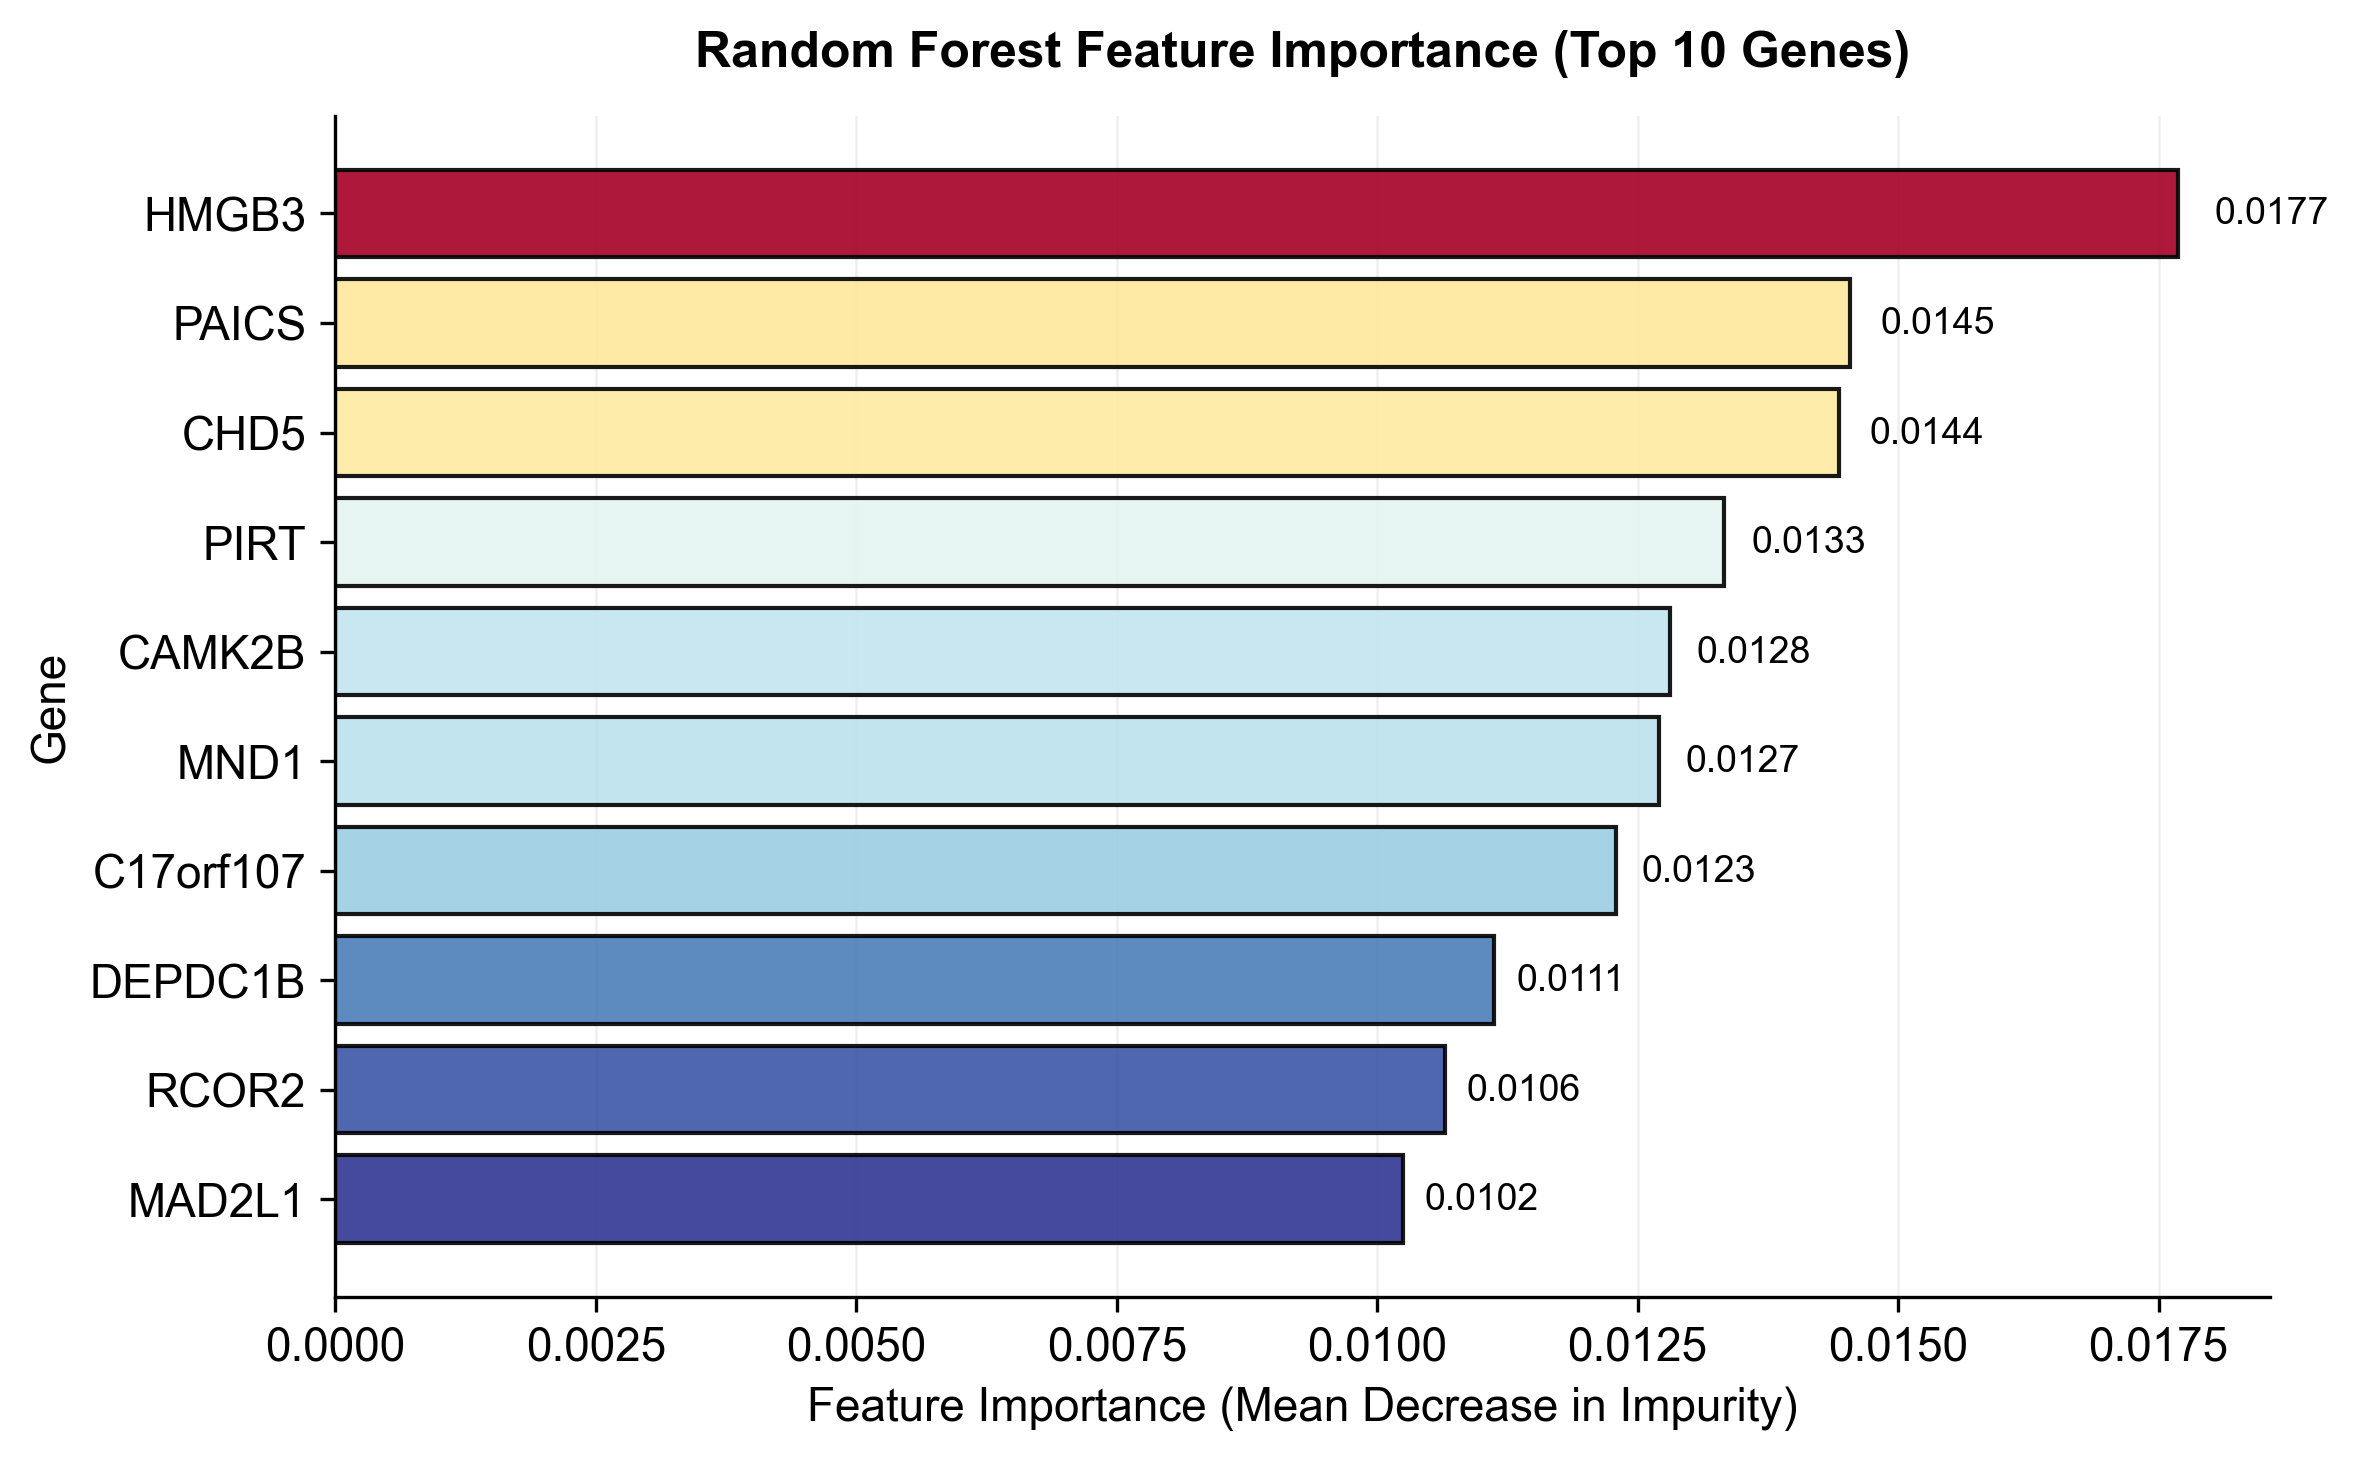

In [31]:
# visualise top 10 important features
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 11

# prepare data
top_n = 10
top_features = feature_importance_df.head(top_n).copy()

# reverse so highest appears at top
top_features = top_features.iloc[::-1]

# normalise importance for colour mapping
norm = (top_features['Importance'] - top_features['Importance'].min()) / \
       (top_features['Importance'].max() - top_features['Importance'].min())

colors = plt.cm.RdYlBu_r(norm)

# plot
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

bars = ax.barh(
    range(len(top_features)),
    top_features['Importance'],
    color=colors,
    edgecolor='black',
    linewidth=1.0,
    alpha=0.9
)

# value labels
for bar, val in zip(bars, top_features['Importance']):
    ax.text(
        val + val * 0.02,
        bar.get_y() + bar.get_height()/2,
        f'{val:.4f}',
        va='center',
        fontsize=9
    )

ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Gene'])
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
ax.set_ylabel('Gene')

ax.set_title(
    'Random Forest Feature Importance (Top 10 Genes)',
    fontsize=12,
    fontweight='bold',
    pad=12
)

ax.grid(axis='x', linestyle='-', linewidth=0.6, alpha=0.3, color='#CCCCCC')
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# save
plt.savefig('plots/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()


- PIRT: most important feature in the model, previous studies have linked its expression to poor survival in neuroblastoma (Olsson et al., 2016). 
- CDKN3: known to be associated with poor survival, with roles in cell cycle regulation and tumour differentiation (Vernaza et al., 2024). Higher CDKN3 expression has been linked to increased proliferation and reduced differentiation, which are typical features of more aggressive tumours.

Overall, this suggests that the model is capturing biologically meaningful differences between risk groups rather than random patterns. However, it is important to note that feature importance from random forest reflects association rather than causation and may be influenced by correlated genes, so further validation would be needed.



### Limitations

- Small test set (~50 samples)
- Potential overfitting despite CV
- No external validation dataset
- Correlated features affecting importance